# **Importing required libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [ ]:
SCM = pd.read_csv("supply_chain_data.csv")

In [ ]:
df = SCM.copy()

# **Data overview**

In [ ]:
df.shape

(25000, 24)

In [ ]:
df.head()

,Ware_house_ID,WH_Manager_ID,Location_type,WH_capacity_size,zone,WH_regional_zone,num_refill_req_l3m,transport_issue_l1y,Competitor_in_mkt,retail_shop_num,...,electric_supply,dist_from_hub,workers_num,wh_est_year,storage_issue_reported_l3m,temp_reg_mach,approved_wh_govt_certificate,wh_breakdown_l3m,govt_check_l3m,product_wg_ton
0,WH_100000,EID_50000,Urban,Small,West,Zone 6,3,1,2,4651,...,1,91,29.0,NaN,13,0,A,5,15,17115
1,WH_100001,EID_50001,Rural,Large,North,Zone 5,0,0,4,6217,...,1,210,31.0,NaN,4,0,A,3,17,5074
2,WH_100002,EID_50002,Rural,Mid,South,Zone 2,1,0,4,4306,...,0,161,37.0,NaN,17,0,A,6,22,23137
3,WH_100003,EID_50003,Rural,Mid,North,Zone 3,7,4,2,6000,...,0,103,21.0,NaN,17,1,A+,3,27,22115
4,WH_100004,EID_50004,Rural,Large,North,Zone 5,3,1,2,4740,...,1,112,25.0,2009.0,18,0,C,6,24,24071


In [ ]:
df.tail()

,Ware_house_ID,WH_Manager_ID,Location_type,WH_capacity_size,zone,WH_regional_zone,num_refill_req_l3m,transport_issue_l1y,Competitor_in_mkt,retail_shop_num,...,electric_supply,dist_from_hub,workers_num,wh_est_year,storage_issue_reported_l3m,temp_reg_mach,approved_wh_govt_certificate,wh_breakdown_l3m,govt_check_l3m,product_wg_ton
24995,WH_124995,EID_74995,Rural,Small,North,Zone 1,3,0,4,5390,...,1,142,34.0,2005.0,22,1,A,2,30,32093
24996,WH_124996,EID_74996,Rural,Mid,West,Zone 2,6,0,4,4490,...,1,130,28.0,2012.0,10,0,B,4,18,12114
24997,WH_124997,EID_74997,Urban,Large,South,Zone 5,7,0,2,5403,...,1,147,NaN,NaN,23,0,B+,5,25,27080
24998,WH_124998,EID_74998,Rural,Small,North,Zone 1,1,0,2,10562,...,1,60,25.0,NaN,18,0,A,6,30,25093
24999,WH_124999,EID_74999,Rural,Mid,West,Zone 4,8,2,4,5664,...,1,239,39.0,2019.0,4,0,B+,2,11,5058


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
num_refill_req_l3m,25000.0,4.089040,2.606612,0.0,2.0,4.0,6.0,8.0
transport_issue_l1y,25000.0,0.773680,1.199449,0.0,0.0,0.0,1.0,5.0
Competitor_in_mkt,25000.0,3.104200,1.141663,0.0,2.0,3.0,4.0,12.0
retail_shop_num,25000.0,4985.711560,1052.825252,1821.0,4313.0,4859.0,5500.0,11008.0
distributor_num,25000.0,42.418120,16.064329,15.0,29.0,42.0,56.0,70.0
flood_impacted,25000.0,0.098160,0.297537,0.0,0.0,0.0,0.0,1.0
flood_proof,25000.0,0.054640,0.227281,0.0,0.0,0.0,0.0,1.0
electric_supply,25000.0,0.656880,0.474761,0.0,0.0,1.0,1.0,1.0
dist_from_hub,25000.0,163.537320,62.718609,55.0,109.0,164.0,218.0,271.0
workers_num,24010.0,28.944398,7.872534,10.0,24.0,28.0,33.0,98.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ware_house_ID                 25000 non-null  object 
 1   WH_Manager_ID                 25000 non-null  object 
 2   Location_type                 25000 non-null  object 
 3   WH_capacity_size              25000 non-null  object 
 4   zone                          25000 non-null  object 
 5   WH_regional_zone              25000 non-null  object 
 6   num_refill_req_l3m            25000 non-null  int64  
 7   transport_issue_l1y           25000 non-null  int64  
 8   Competitor_in_mkt             25000 non-null  int64  
 9   retail_shop_num               25000 non-null  int64  
 10  wh_owner_type                 25000 non-null  object 
 11  distributor_num               25000 non-null  int64  
 12  flood_impacted                25000 non-null  int64  
 13  f

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()/len(df)*100

,0
Ware_house_ID,0.000
WH_Manager_ID,0.000
Location_type,0.000
WH_capacity_size,0.000
zone,0.000
WH_regional_zone,0.000
num_refill_req_l3m,0.000
transport_issue_l1y,0.000
Competitor_in_mkt,0.000
retail_shop_num,0.000


In [ ]:
df['workers_num'].unique()

array([29., 31., 37., 21., 25., 35., 27., 23., 22., 43., 16., 28., 36.,
       19., 24., 41., 20., 17., 46., 30., 33., 32., nan, 26., 38., 39.,
       40., 34., 44., 18., 11., 12., 42., 45., 47., 15., 48., 50., 62.,
       49., 56., 53., 98., 14., 55., 54., 61., 10., 51., 57., 78., 52.,
       13., 92., 65., 60., 64., 72., 58., 67., 63.])

In [ ]:
df['wh_est_year'].unique()

array([  nan, 2009., 2010., 2013., 1999., 2017., 2022., 2008., 2001.,
       2016., 1997., 2003., 2006., 2019., 2015., 2012., 1998., 2021.,
       2004., 2000., 2005., 2011., 2014., 1996., 2020., 2023., 2002.,
       2007., 2018.])

In [ ]:
df['approved_wh_govt_certificate'].unique()

array(['A', 'A+', 'C', 'B', 'B+', nan], dtype=object)

The dataset was imported using pandas and a copy was created for analysis. Basic structure, data types, descriptive statistics, duplicate checks, and missing value percentages were examined to understand data quality and structure before analysis.

# **Exploratory Data Analysis- Target Variable**

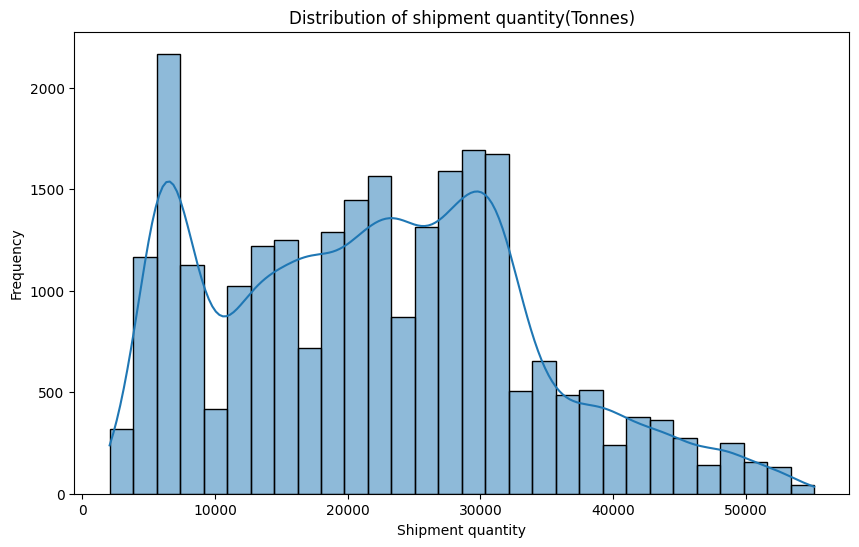

In [ ]:
# EDA- Target variable analysis

#Histogram
plt.figure(figsize =(10,6))
sns.histplot(df['product_wg_ton'],bins=30, kde=True)
plt.title('Distribution of shipment quantity(Tonnes)')
plt.xlabel('Shipment quantity')
plt.ylabel('Frequency')
plt.show()

• Shipment demand varies widely between warehouses, ranging
roughly from 3,000 to 55,000 tons, meaning customer consumption is
not uniform across regions and market size differs significantly.

• The distribution forms multiple demand clusters around 6k–9k, 18k–
25k, and 28k–35k tons, indicating the presence of low-, medium-, and
high-consumption markets such as rural, semi-urban, and urban
areas.

• A small number of warehouses require extremely large shipments
above 50,000 tons, showing densely populated or high retail activity
regions where products move much faster.

• Because demand differs so much across locations, a single fixed
supply strategy will not work and shipment allocation needs
prediction-based planning.

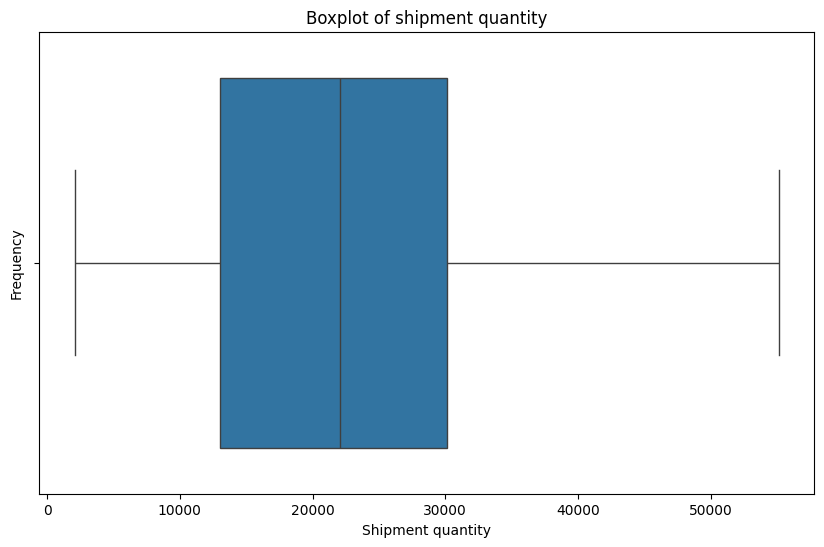

In [ ]:
#Boxplot
plt.figure(figsize= (10,6))
sns.boxplot(x=df['product_wg_ton'])
plt.title('Boxplot of shipment quantity')
plt.xlabel('Shipment quantity')
plt.ylabel('Frequency')
plt.show()

• The middle 50% of warehouses ship roughly between about 13,000
and 30,000 tons, which means most locations operate in a moderate
demand range.

• The median shipment is around 22,000 tons, indicating a typical
warehouse requirement close to this level.

• Some warehouses ship very low quantities near 3,000 tons while
others go beyond 55,000 tons, showing very large differences in
regional demand.

• The wide spread of shipment quantities indicates supply planning
cannot be standardized and must be customized per warehouse.

# **Exploratory Data Analysis- Univariate Analysis**

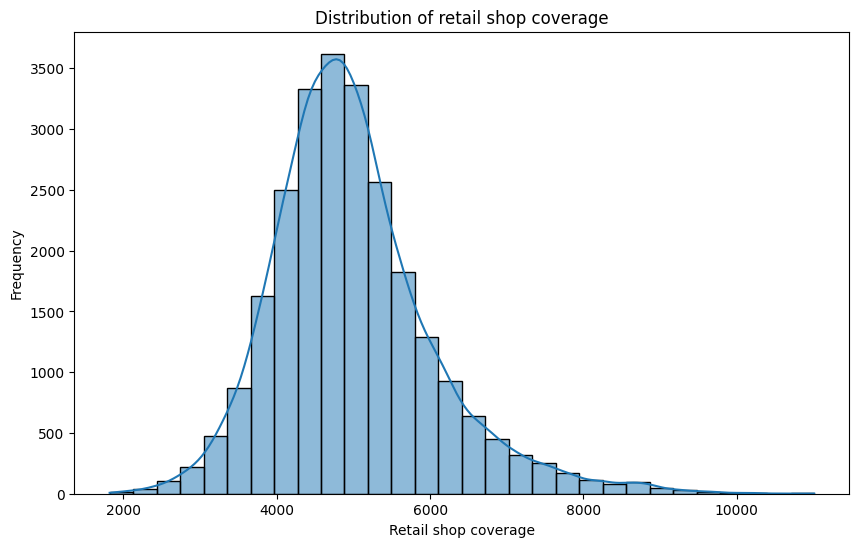

In [ ]:
#EDA-Univariate Analysis

#Retail shop coverage

plt.figure(figsize = (10,6))
sns.histplot(df["retail_shop_num"], bins=30, kde=True)
plt.title('Distribution of retail shop coverage')
plt.xlabel('Retail shop coverage')
plt.ylabel('Frequency')
plt.show()

• Most warehouses serve around 4,000 to 6,000 retail shops, showing a
standard operating coverage size for the company.

• Very few warehouses serve extremely large networks above 8,000–
10,000 shops, indicating major high-demand markets.

• The distribution is slightly right-skewed, meaning there are more
medium-coverage warehouses and only a small number of very large
coverage regions.

• Since shipment quantity depends on retail coverage, warehouses
with larger retail networks are expected to require higher product
allocation.

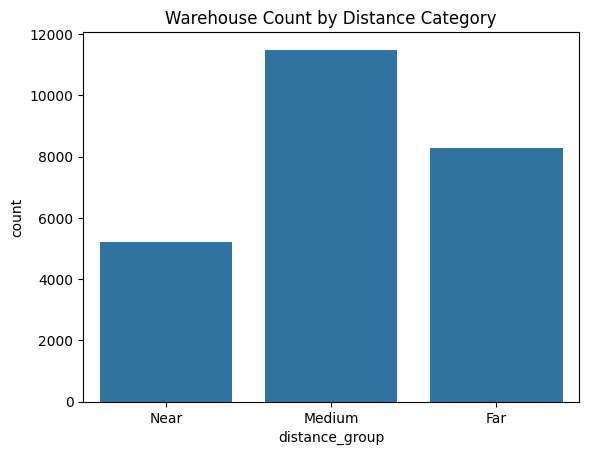

In [ ]:
#Distance from hub

df['distance_group'] = pd.cut(df['dist_from_hub'],
                              bins=[0,100,200,300],
                              labels=['Near','Medium','Far'])

sns.countplot(x='distance_group', data=df)
plt.title("Warehouse Count by Distance Category")
plt.show()




• Most warehouses fall in the medium distance range, showing the
company primarily serves moderately distant regions from the
production hub.

• A considerable number of warehouses are also located in far regions,
indicating the supply network extends to remote markets.

• Fewer warehouses are located in the near category, suggesting the
company is not concentrated only around the production facility.

• Overall, the warehouse network is geographically distributed rather
than centralized near the factory.

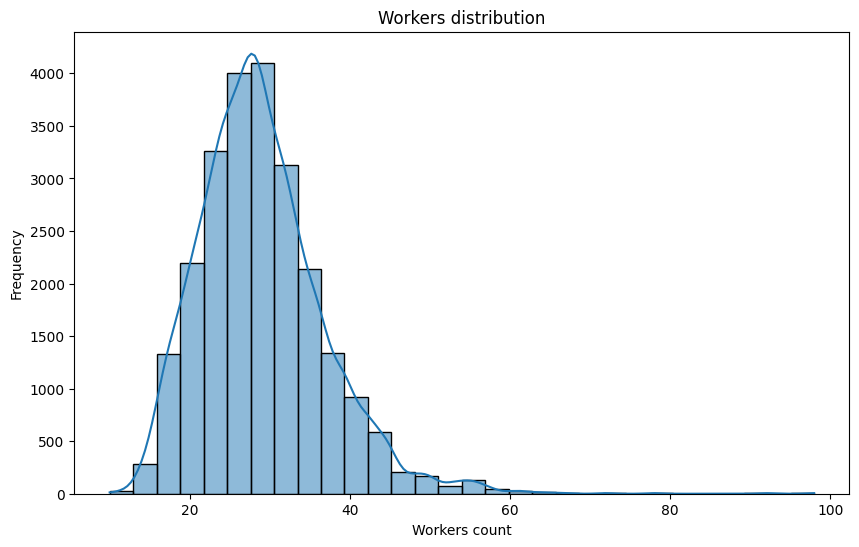

In [ ]:
#workers count

plt.figure (figsize = (10,6))
sns.histplot(df["workers_num"], bins=30, kde=True)
plt.title('Workers distribution')
plt.xlabel('Workers count')
plt.ylabel('Frequency')
plt.show()

• Most warehouses employ around 20 to 35 workers, indicating a
standard staffing size across the company’s operations.

• Very few warehouses have a large workforce above 50 workers,
suggesting only a small number of high-capacity or high-activity
locations.

• The distribution is right-skewed, meaning many warehouses operate
with moderate manpower while only a few require significantly larger
teams.

• This shows the company maintains fairly uniform operational scale
across warehouses with limited extremely large facilities.

## **Exploratory Data Analysis- Bivariate Analysis**

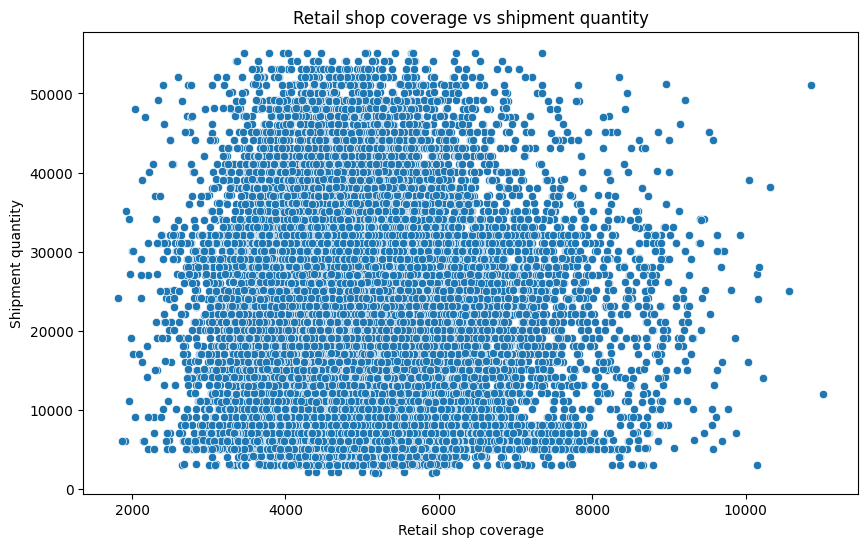

In [ ]:
#EDA-Bivariate Analysis
#Retail shop vs shipment

plt.figure(figsize=(10,6))
sns.scatterplot(x=df["retail_shop_num"], y=df["product_wg_ton"])
plt.title('Retail shop coverage vs shipment quantity')
plt.xlabel('Retail shop coverage')
plt.ylabel('Shipment quantity')
plt.show()

• Shipment quantity generally increases as retail shop coverage
increases, indicating warehouses serving more stores require higher
product supply.

• Warehouses with low retail coverage mostly receive lower shipment
quantities, while high-coverage warehouses frequently receive higher
stock volumes.

• The spread is wide, meaning retail coverage is a strong driver but not
the only factor influencing shipment allocation.

• This confirms retail presence is a key demand indicator used for
supply planning.

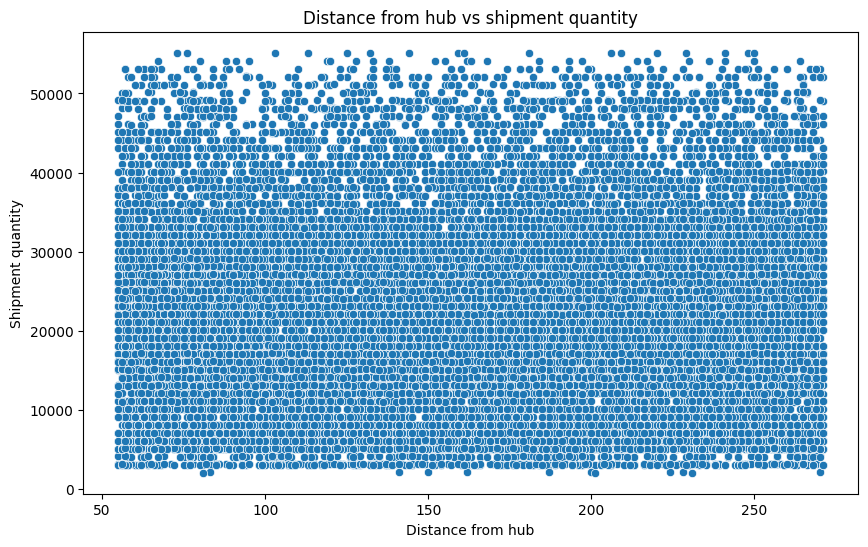

In [ ]:
#Distance vs shipment

plt.figure(figsize=(10,6))
sns.scatterplot(x=df["dist_from_hub"], y=df["product_wg_ton"])
plt.title('Distance from hub vs shipment quantity')
plt.xlabel('Distance from hub')
plt.ylabel('Shipment quantity')
plt.show()

• Shipment quantities are distributed almost evenly across all distance
ranges, showing no clear increasing or decreasing trend.

• Warehouses located both near and far from the production hub
receive similar shipment volumes.

• This indicates distance does not significantly influence demand-
based allocation decisions.

• Distance acts more as a logistics planning factor rather than a
demand determinant.

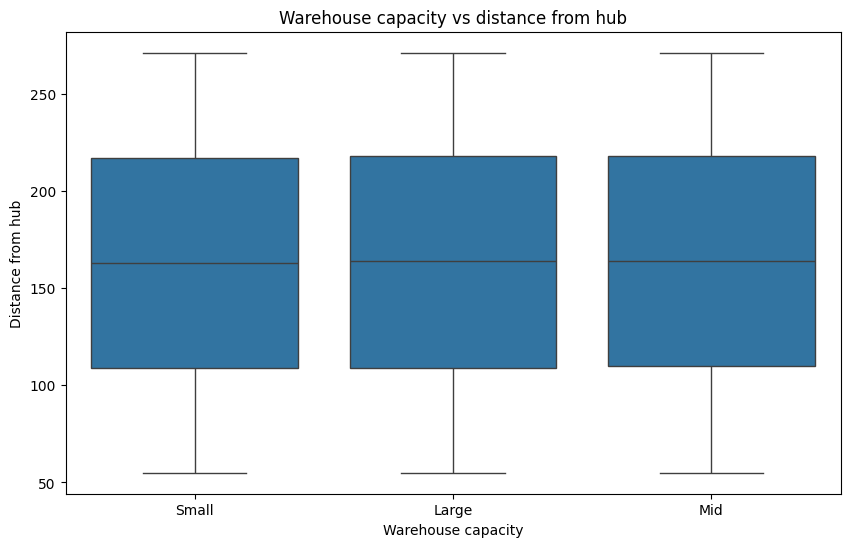

In [ ]:
#Warehouse capacity vs distance

plt.figure(figsize=(10, 6))
sns.boxplot(x=df["WH_capacity_size"], y=df["dist_from_hub"])
plt.title('Warehouse capacity vs distance from hub')
plt.xlabel('Warehouse capacity')
plt.ylabel('Distance from hub')
plt.show()

• All capacity categories (Small, Medium, Large) are spread across
similar distance ranges, showing no major placement difference
based on size.

• The median distance for each capacity type is nearly the same,
meaning large warehouses are not specifically located closer to the
production hub.

• This suggests warehouse size is determined by regional demand
needs rather than proximity to the factory.

• The company distributes infrastructure across locations instead of
centralizing large warehouses near the hub.

Text(0.5, 1.0, 'Zone vs shipment quantity')

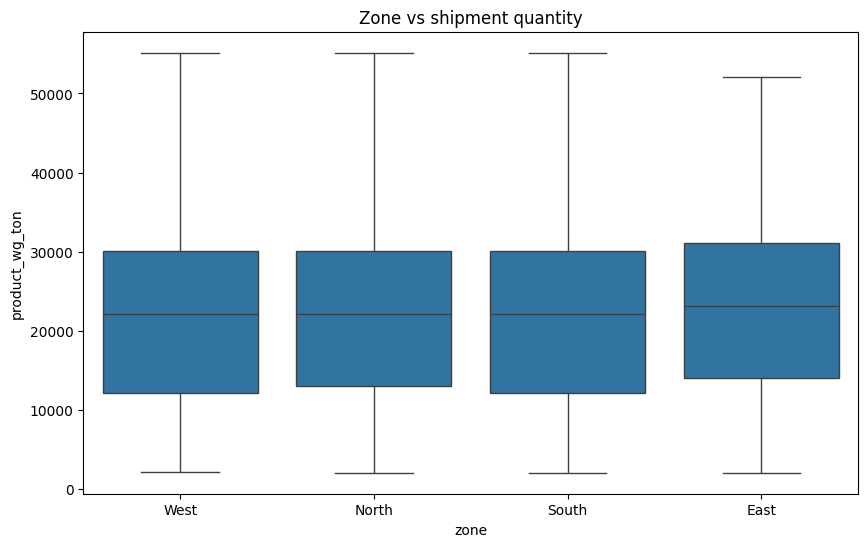

In [ ]:
#zone vs shipment

plt.figure(figsize=(10,6))
sns.boxplot(x=df["zone"], y=df["product_wg_ton"])
plt.title('Zone vs shipment quantity')

• All zones show a broadly similar shipment range, indicating the
product has demand across the entire market.

• The East zone has a slightly higher median shipment compared to
other zones, suggesting relatively stronger demand in that region.

• The spread of shipment values is wide in every zone, meaning both
low- and high-demand markets exist within each region.

• No single zone dominates completely, so demand variation is more
local-market driven than purely regional.

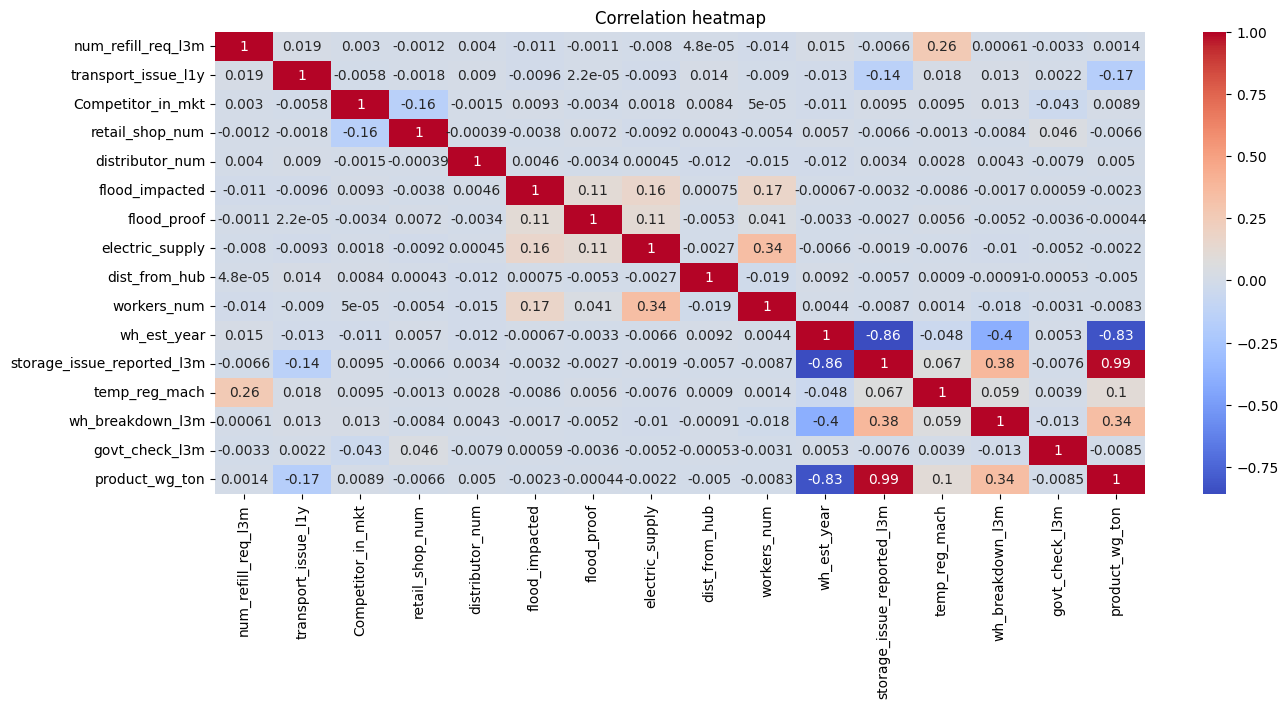

In [ ]:
#EDA- Multivariate analysis(Correlation heatmap)

plt.figure(figsize=(15,6))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation heatmap')
plt.show()

• Storage issue reported shows shows an extremely high positive
correlation with shipment quantity (~0.99), indicating potential data
leakage since it almost directly reflects shipment levels

• Warehouse established year has a strong negative correlation with
shipment quantity (~ -0.83), suggesting older warehouses (larger age)
tend to handle higher shipment volumes.

• Warehouse Breakdown shows a moderate positive relationship with
shipment (~0.34), meaning high-activity warehouses experience more
operational breakdown events.

• Most other variables show weak correlations with shipment,
indicating shipment allocation depends on a combination of multiple
factors rather than a single dominant feature.

Exploratory analysis was conducted using histograms, boxplots, count plots, scatter plots, and correlation heatmaps. Univariate analysis was used to understand individual variable distributions, bivariate analysis examined relationships with shipment quantity, and multivariate analysis identified correlations among numerical features.

## **Data preprocessing**

In [ ]:
df.drop(['Ware_house_ID', 'WH_Manager_ID','storage_issue_reported_l3m',], axis=1, inplace=True)

In [ ]:
df['warehouse_age'] = 2026 - df['wh_est_year']
df.drop('wh_est_year', axis=1, inplace=True)


Identifier variables such as warehouse and manager IDs were removed as they do not influence shipment prediction. Before cleaning, irrelevant identifiers added noise and no analytical value; after removal, the dataset became more meaningful and ready for modeling

# **Duplicate value check and treatment** - no duplicate values present

In [ ]:
df.duplicated().sum()

np.int64(0)

Duplicate records were checked and none were found.

# **Missing value Treatment**

In [ ]:
df.isnull().sum()/len(df)*100

,0
Location_type,0.000
WH_capacity_size,0.000
zone,0.000
WH_regional_zone,0.000
num_refill_req_l3m,0.000
transport_issue_l1y,0.000
Competitor_in_mkt,0.000
retail_shop_num,0.000
wh_owner_type,0.000
distributor_num,0.000


In [ ]:
df['warehouse_age'].unique()

array([nan, 17., 16., 13., 27.,  9.,  4., 18., 25., 10., 29., 23., 20.,
        7., 11., 14., 28.,  5., 22., 26., 21., 15., 12., 30.,  6.,  3.,
       24., 19.,  8.])

In [ ]:
df['age_missing_flag'] = df['warehouse_age'].isnull().astype(int)
df['warehouse_age'].fillna(df['warehouse_age'].median(), inplace=True)

In [ ]:
df['workers_num'].fillna(df['workers_num'].median(), inplace=True)

df['approved_wh_govt_certificate'].fillna(df['approved_wh_govt_certificate'].mode()[0], inplace = True)

In [ ]:
df.isnull().sum()

,0
Location_type,0
WH_capacity_size,0
zone,0
WH_regional_zone,0
num_refill_req_l3m,0
transport_issue_l1y,0
Competitor_in_mkt,0
retail_shop_num,0
wh_owner_type,0
distributor_num,0


A key variable warehouse_age had 47.52% missing values and was removed, while smaller gaps like workers_num (3.96%) and govt certificate (3.63%) were imputed using median and mode. Before treatment, missing data reduced usable information and risked biased analysis; after imputation, missingness was reduced to 0%, making the dataset complete and reliable for modeling.

# **Outlier Treatment**

In [ ]:
cont_cols = ['retail_shop_num','workers_num','warehouse_age','product_wg_ton']

def treat_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    df[col] = np.clip(df[col], lower, upper)

for col in cont_cols:
    treat_outliers(col)


Shipment quantity ranged widely from ~3K to ~55K tons, with similar extreme spreads in workforce and retail coverage. Before treatment, extreme values could distort statistical patterns and influence learning disproportionately; after IQR-based capping, distributions became more stable and suitable for predictive modeling while preserving genuine business variability.

**Feature Engineering**

In [ ]:
#1. Infrastructure score

df['Infrastructure_score'] = (df['electric_supply'] + df['temp_reg_mach'] + df['flood_proof'])

In [ ]:
#2. Risk score

df['risk_score'] = (df['flood_impacted'] + df['transport_issue_l1y']+ df['wh_breakdown_l3m'])

New operational features were engineered, including Infrastructure Score and Risk Score, by combining relevant operational indicators to better capture warehouse performance and risk characteristics.

Class imbalance handling was not required because the problem is a regression task predicting a continuous shipment quantity rather than a classification problem with categorical classes.

**Encoding categorical variables**

In [ ]:
df = pd.get_dummies(df, drop_first=True)

Warehouse age was derived to better represent operational maturity, and categorical variables were converted using one-hot encoding. Before transformation, categorical data could not be used by ML algorithms; after encoding and feature creation, predictors became machine-readable and more informative for analysis.

Feature scaling and data preparation for modelling

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

scaler = StandardScaler()

x = df.drop('product_wg_ton', axis=1)
y = df['product_wg_ton']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

The dataset was split into training and testing sets (80:20 split). Numerical variables were standardized for Linear Regression to ensure equal contribution during optimization. Before scaling, large-magnitude features could dominate coefficient estimation; after scaling, feature influence became balanced, improving training stability.

Base line model Building- Linear Regression model

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

lr = LinearRegression()
lr.fit(x_train_scaled, y_train)

LinearRegression()

The target variable product_wg_ton represents shipment quantity in tons, which is a continuous numerical value. Since the objective is to predict a numeric amount rather than a categorical outcome, a regression approach is appropriate. Linear Regression was selected as the baseline model due to its simplicity, interpretability, and its ability to establish a reference performance benchmark for more advanced models.

In [ ]:
#Predictions

y_pred_train = lr.predict(x_train_scaled)
y_pred_test = lr.predict(x_test_scaled)

In [ ]:
#Model evaluation metrics

#Training performance

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
mae_train = mean_absolute_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)

print("Training rmse", rmse_train)
print("Training mae", mae_train)
print("Training r2", r2_train)

Training rmse 8614.891977776228
Training mae 6940.8131216611655
Training r2 0.45011903378194074


In [ ]:
#Test performance

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print("Test rmse", rmse_test)
print("Test mae", mae_test)
print("Test r2", r2_test)

Test rmse 8560.650777711955
Test mae 6924.631011148508
Test r2 0.4522808711754146


RMSE was selected as the primary evaluation metric because shipment prediction errors directly translate into inventory cost. Larger errors result in overstock or stockout losses, and RMSE penalizes large errors more strongly than MAE, making it suitable for supply chain planning.

The model performance was evaluated using RMSE, MAE, and R² on both training and testing datasets. The training and testing results are very similar, indicating the model generalizes well and does not overfit. The RMSE of approximately 8.5 thousand tons represents the average prediction error in shipment quantity, while the MAE of around 6.9 thousand tons shows the typical difference between predicted and actual shipments. The R² value of about 0.45 indicates the model explains nearly half of the variation in shipment demand. Overall, the baseline model provides a reasonable prediction benchmark for comparing more advanced machine learning models.

**Advanced Model Building**

MODEL 1 —
Decision Tree Regressor



In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

dt = DecisionTreeRegressor(random_state=42)
dt.fit(x_train, y_train)

# Predictions
y_pred_train_dt = dt.predict(x_train)
y_pred_test_dt  = dt.predict(x_test)

# Train Metrics
rmse_train_dt = np.sqrt(mean_squared_error(y_train, y_pred_train_dt))
mae_train_dt  = mean_absolute_error(y_train, y_pred_train_dt)
r2_train_dt   = r2_score(y_train, y_pred_train_dt)

# Test Metrics
rmse_test_dt = np.sqrt(mean_squared_error(y_test, y_pred_test_dt))
mae_test_dt  = mean_absolute_error(y_test, y_pred_test_dt)
r2_test_dt   = r2_score(y_test, y_pred_test_dt)

print("Decision Tree Performance")
print("Train RMSE:", rmse_train_dt)
print("Train MAE :", mae_train_dt)
print("Train R2  :", r2_train_dt)
print("Test RMSE :", rmse_test_dt)
print("Test MAE  :", mae_test_dt)
print("Test R2   :", r2_test_dt)


Decision Tree Performance
Train RMSE: 0.0
Train MAE : 0.0
Train R2  : 1.0
Test RMSE : 11265.232302868859
Test MAE  : 8529.666
Test R2   : 0.05152770264005413


Model performance showed perfect training fit (RMSE 0, R² 1.0) but very poor test results with RMSE ~11.3K tons, MAE ~8.5K tons, and R² ~0.05, indicating severe overfitting. While the model memorizes historical data, it fails to predict new demand accurately. In business terms, this would lead to unreliable shipment planning and major inventory mismatches.

MODEL 2 — Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(x_train, y_train)

# Predictions
y_pred_train_rf = rf.predict(x_train)
y_pred_test_rf  = rf.predict(x_test)

# Train Metrics
rmse_train_rf = np.sqrt(mean_squared_error(y_train, y_pred_train_rf))
mae_train_rf  = mean_absolute_error(y_train, y_pred_train_rf)
r2_train_rf   = r2_score(y_train, y_pred_train_rf)

# Test Metrics
rmse_test_rf = np.sqrt(mean_squared_error(y_test, y_pred_test_rf))
mae_test_rf  = mean_absolute_error(y_test, y_pred_test_rf)
r2_test_rf   = r2_score(y_test, y_pred_test_rf)

print("\nRandom Forest Performance")
print("Train RMSE:", rmse_train_rf)
print("Train MAE :", mae_train_rf)
print("Train R2  :", r2_train_rf)
print("Test RMSE :", rmse_test_rf)
print("Test MAE  :", mae_test_rf)
print("Test R2   :", r2_test_rf)



Random Forest Performance
Train RMSE: 3056.0394426299154
Train MAE : 2363.9414625
Train R2  : 0.9308030543716235
Test RMSE : 8070.303265460091
Test MAE  : 6309.053895999999
Test R2   : 0.5132297171214225


Random Forest achieved strong training performance and good generalization with test RMSE ~8.07K tons, MAE ~6.31K tons, and R² ~0.51. The smaller train–test gap indicates stable learning of demand patterns. From a business perspective, this enables more dependable shipment allocation and reduces the risk of stockouts and excess inventory.

MODEL 3 — Gradient Boosting Regressor

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=42)
gb.fit(x_train, y_train)

# Predictions
y_pred_train_gb = gb.predict(x_train)
y_pred_test_gb  = gb.predict(x_test)

# Train Metrics
rmse_train_gb = np.sqrt(mean_squared_error(y_train, y_pred_train_gb))
mae_train_gb  = mean_absolute_error(y_train, y_pred_train_gb)
r2_train_gb   = r2_score(y_train, y_pred_train_gb)

# Test Metrics
rmse_test_gb = np.sqrt(mean_squared_error(y_test, y_pred_test_gb))
mae_test_gb  = mean_absolute_error(y_test, y_pred_test_gb)
r2_test_gb   = r2_score(y_test, y_pred_test_gb)

print("\nGradient Boosting Performance")
print("Train RMSE:", rmse_train_gb)
print("Train MAE :", mae_train_gb)
print("Train R2  :", r2_train_gb)
print("Test RMSE :", rmse_test_gb)
print("Test MAE  :", mae_test_gb)
print("Test R2   :", r2_test_gb)



Gradient Boosting Performance
Train RMSE: 7954.313168276607
Train MAE : 6251.4050294579965
Train R2  : 0.5312142671202575
Test RMSE : 7932.107758276537
Test MAE  : 6236.368947558187
Test R2   : 0.5297578460619743


Gradient Boosting showed balanced training and testing performance with test RMSE ~7.93K tons, MAE ~6.24K tons, and R² ~0.53. Similar train–test metrics indicate good generalization and effective learning of complex demand relationships. In business terms, this supports more accurate forecasting and improved supply planning efficiency.

MODEL 4- AdaBoost

In [ ]:
from sklearn.ensemble import AdaBoostRegressor

ada = AdaBoostRegressor(random_state=42)
ada.fit(x_train, y_train)

y_pred_train_ada = ada.predict(x_train)
y_pred_test_ada  = ada.predict(x_test)

rmse_train_ada = np.sqrt(mean_squared_error(y_train, y_pred_train_ada))
mae_train_ada  = mean_absolute_error(y_train, y_pred_train_ada)
r2_train_ada   = r2_score(y_train, y_pred_train_ada)

rmse_test_ada = np.sqrt(mean_squared_error(y_test, y_pred_test_ada))
mae_test_ada  = mean_absolute_error(y_test, y_pred_test_ada)
r2_test_ada   = r2_score(y_test, y_pred_test_ada)

print("\nAdaBoost Performance")
print("Train RMSE:", rmse_train_ada)
print("Train MAE :", mae_train_ada)
print("Train R2  :", r2_train_ada)
print("Test RMSE :", rmse_test_ada)
print("Test MAE  :", mae_test_ada)
print("Test R2   :", r2_test_ada)



AdaBoost Performance
Train RMSE: 8690.787142278139
Train MAE : 7150.668285853731
Train R2  : 0.4403877134626344
Test RMSE : 8597.581083340121
Test MAE  : 7061.069878760275
Test R2   : 0.44754500108204753


AdaBoost delivered moderate and stable performance with test RMSE ~8.60K tons, MAE ~7.06K tons, and R² ~0.45. The model captures some demand patterns but shows limited accuracy improvement. From a business standpoint, forecasting based on this model may still result in noticeable inventory imbalances.

MODEL 5 - XGBoost

In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=42, verbosity=0)
xgb.fit(x_train, y_train)

y_pred_train_xgb = xgb.predict(x_train)
y_pred_test_xgb  = xgb.predict(x_test)

rmse_train_xgb = np.sqrt(mean_squared_error(y_train, y_pred_train_xgb))
mae_train_xgb  = mean_absolute_error(y_train, y_pred_train_xgb)
r2_train_xgb   = r2_score(y_train, y_pred_train_xgb)

rmse_test_xgb = np.sqrt(mean_squared_error(y_test, y_pred_test_xgb))
mae_test_xgb  = mean_absolute_error(y_test, y_pred_test_xgb)
r2_test_xgb   = r2_score(y_test, y_pred_test_xgb)

print("\nXGBoost Performance")
print("Train RMSE:", rmse_train_xgb)
print("Train MAE :", mae_train_xgb)
print("Train R2  :", r2_train_xgb)
print("Test RMSE :", rmse_test_xgb)
print("Test MAE  :", mae_test_xgb)
print("Test R2   :", r2_test_xgb)



XGBoost Performance
Train RMSE: 6080.689105685309
Train MAE : 4687.07275390625
Train R2  : 0.7260478734970093
Test RMSE : 8276.484277759488
Test MAE  : 6487.90625
Test R2   : 0.48803985118865967


XGBoost demonstrated strong learning capability with test RMSE ~8.28K tons, MAE ~6.49K tons, and R² ~0.49. The model effectively captures complex patterns with acceptable generalization. In business terms, this provides reliable demand forecasts and supports better logistics and inventory coordination.

Hyperparameter Tuning — Model 1: Gradient Boosting

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor

gb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0]
}


In [ ]:
gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_params,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

gb_grid.fit(x_train, y_train)
best_gb = gb_grid.best_estimator_


In [ ]:
y_pred_train_gb_t = best_gb.predict(x_train)
y_pred_test_gb_t  = best_gb.predict(x_test)

rmse_train_gb_t = np.sqrt(mean_squared_error(y_train, y_pred_train_gb_t))
mae_train_gb_t  = mean_absolute_error(y_train, y_pred_train_gb_t)
r2_train_gb_t   = r2_score(y_train, y_pred_train_gb_t)

rmse_test_gb_t = np.sqrt(mean_squared_error(y_test, y_pred_test_gb_t))
mae_test_gb_t  = mean_absolute_error(y_test, y_pred_test_gb_t)
r2_test_gb_t   = r2_score(y_test, y_pred_test_gb_t)

print("Tuned Gradient Boosting Performance")

print("\nTrain Metrics")
print("Train RMSE:", rmse_train_gb_t)
print("Train MAE :", mae_train_gb_t)
print("Train R2  :", r2_train_gb_t)

print("\nTest Metrics")
print("Test RMSE :", rmse_test_gb_t)
print("Test MAE  :", mae_test_gb_t)
print("Test R2   :", r2_test_gb_t)


Tuned Gradient Boosting Performance

Train Metrics
Train RMSE: 7789.409040198618
Train MAE : 6091.931996060063
Train R2  : 0.5504499655830557

Test Metrics
Test RMSE : 7907.655412960518
Test MAE  : 6193.047662559538
Test R2   : 0.5326526126496816


After hyperparameter tuning, the model achieved a test RMSE of ~7.91K tons, MAE ~6.19K tons, and R² ~0.533 with very similar training results, indicating strong generalization. The reduced error shows improved prediction precision. In business terms, this enables more accurate shipment planning and lowers the risk of inventory imbalance across warehouses.

Hyperparameter Tuning — Model 2: Random Forest

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [ ]:
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

In [ ]:
rf_grid.fit(x_train, y_train)
best_rf = rf_grid.best_estimator_

print("Best Parameters:", rf_grid.best_params_)

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}


In [ ]:
y_pred_train_rf_t = best_rf.predict(x_train)
y_pred_test_rf_t  = best_rf.predict(x_test)

rmse_train_rf_t = np.sqrt(mean_squared_error(y_train, y_pred_train_rf_t))
mae_train_rf_t  = mean_absolute_error(y_train, y_pred_train_rf_t)
r2_train_rf_t   = r2_score(y_train, y_pred_train_rf_t)

rmse_test_rf_t = np.sqrt(mean_squared_error(y_test, y_pred_test_rf_t))
mae_test_rf_t  = mean_absolute_error(y_test, y_pred_test_rf_t)
r2_test_rf_t   = r2_score(y_test, y_pred_test_rf_t)

print("Tuned Random Forest Performance")

print("\nTrain Metrics")
print("Train RMSE:", rmse_train_rf_t)
print("Train MAE :", mae_train_rf_t)
print("Train R2  :", r2_train_rf_t)

print("\nTest Metrics")
print("Test RMSE :", rmse_test_rf_t)
print("Test MAE  :", mae_test_rf_t)
print("Test R2   :", r2_test_rf_t)

Tuned Random Forest Performance

Train Metrics
Train RMSE: 7405.763072268782
Train MAE : 5723.031842361176
Train R2  : 0.5936421607153383

Test Metrics
Test RMSE : 7930.328993190449
Test MAE  : 6206.308896099134
Test R2   : 0.5299687248257173


Tuning improved Random Forest performance to a test RMSE of ~7.93K tons, MAE ~6.21K tons, and R² ~0.53 with a controlled train–test gap. The model shows stable and reliable demand prediction. From a business perspective, this supports better inventory distribution, improved warehouse utilization, and reduced logistics inefficiencies.

Final Tuning — XGBoost

In [ ]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

In [ ]:
xgb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

In [ ]:

xgb_grid = GridSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    xgb_params,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

In [ ]:
xgb_grid.fit(x_train, y_train)
best_xgb = xgb_grid.best_estimator_

print("Best Parameters:", xgb_grid.best_params_)

Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}


In [ ]:
y_pred_train_xgb_t = best_xgb.predict(x_train)
y_pred_test_xgb_t  = best_xgb.predict(x_test)

rmse_train_xgb_t = np.sqrt(mean_squared_error(y_train, y_pred_train_xgb_t))
mae_train_xgb_t  = mean_absolute_error(y_train, y_pred_train_xgb_t)
r2_train_xgb_t   = r2_score(y_train, y_pred_train_xgb_t)

rmse_test_xgb_t = np.sqrt(mean_squared_error(y_test, y_pred_test_xgb_t))
mae_test_xgb_t  = mean_absolute_error(y_test, y_pred_test_xgb_t)
r2_test_xgb_t   = r2_score(y_test, y_pred_test_xgb_t)

print("\nTuned XGBoost Performance")

print("\nTrain Metrics")
print("Train RMSE:", rmse_train_xgb_t)
print("Train MAE :", mae_train_xgb_t)
print("Train R2  :", r2_train_xgb_t)

print("\nTest Metrics")
print("Test RMSE :", rmse_test_xgb_t)
print("Test MAE  :", mae_test_xgb_t)
print("Test R2   :", r2_test_xgb_t)


Tuned XGBoost Performance

Train Metrics
Train RMSE: 7764.353933200109
Train MAE : 6066.10791015625
Train R2  : 0.5533373355865479

Test Metrics
Test RMSE : 7904.162447723351
Test MAE  : 6197.1650390625
Test R2   : 0.5330654382705688


Tuned XGBoost delivered the best results with test RMSE ~7.90K tons, MAE ~6.20K tons, and R² ~0.533, along with consistent training performance. This indicates high predictive accuracy and strong generalization. In business terms, it enables highly dependable demand forecasting, smarter stock allocation, and significant reduction in supply-demand mismatches.

In [ ]:
tuned_results = {
    "Model": [
        "Gradient Boosting (Tuned)",
        "Random Forest (Tuned)",
        "XGBoost (Tuned)"
    ],
    "RMSE": [
        rmse_test_gb_t,
        rmse_test_rf_t,
        rmse_test_xgb_t
    ],
    "MAE": [
        mae_test_gb_t,
        mae_test_rf_t,
        mae_test_xgb_t
    ],
    "R2": [
        r2_test_gb_t,
        r2_test_rf_t,
        r2_test_xgb_t
    ]
}

tuned_df = pd.DataFrame(tuned_results)
tuned_df.sort_values(by="RMSE")


,Model,RMSE,MAE,R2
2,XGBoost (Tuned),7904.162448,6197.165039,0.533065
0,Gradient Boosting (Tuned),7907.655413,6193.047663,0.532653
1,Random Forest (Tuned),7930.328993,6206.308896,0.529969


Model Performance Comparison and Final Model Selection

The tuned ensemble models were compared using RMSE, MAE, and R² metrics on the test dataset to identify the most accurate predictor.

Tuned Gradient Boosting achieved a test RMSE of ~7.91K tons and R² of ~0.533, while Tuned Random Forest recorded an RMSE of ~7.93K tons and R² of ~0.53. Tuned XGBoost delivered the best performance with the lowest RMSE of ~7.90K tons, MAE of ~6.20K tons, and highest R² of ~0.533.

Since XGBoost produced the smallest prediction error and highest explained variance, it was selected as the final model.

The test RMSE indicates shipment forecasts typically deviate by around 7.9 thousand tons, MAE shows the average allocation difference is about 6.2 thousand tons, and R² confirms the model explains over 53% of demand variation. From a business perspective, this level of accuracy enables reliable demand forecasting, optimized inventory allocation, and reduced logistics inefficiencies across warehouse networks.

Residual Distribution Plot

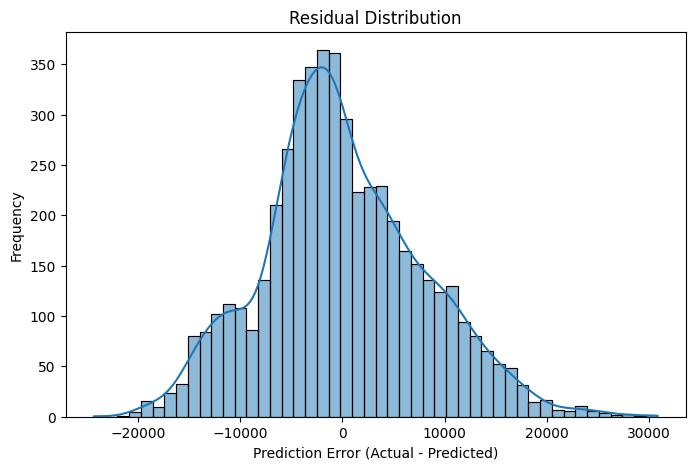

In [ ]:
residuals = y_test - y_pred_test_xgb_t

plt.figure(figsize=(8,5))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Prediction Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.show()

The residuals are centered around zero, indicating that the model does not show systematic overprediction or underprediction. Most errors fall within a moderate range, suggesting stable and consistent forecasting performance. The roughly bell-shaped distribution indicates that prediction errors are random rather than biased. From a business perspective, this means shipment forecasts are generally reliable with manageable deviations.

Actual vs Predicted Plot

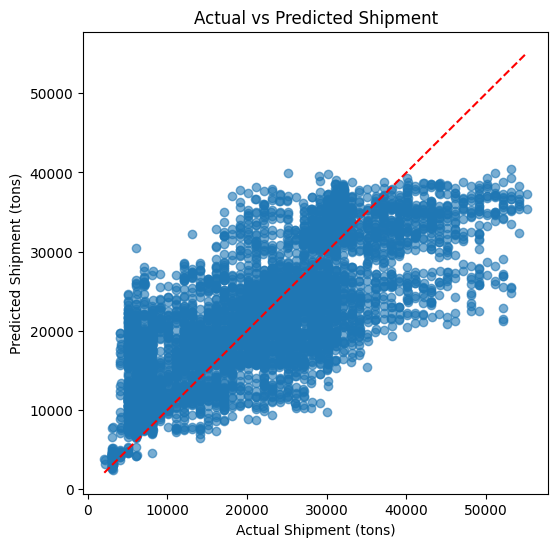

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_test_xgb_t, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.xlabel("Actual Shipment (tons)")
plt.ylabel("Predicted Shipment (tons)")
plt.title("Actual vs Predicted Shipment")
plt.show()


Most data points lie close to the diagonal reference line, indicating strong agreement between actual and predicted shipment quantities. This shows the model captures overall demand patterns effectively. Some dispersion is visible at higher shipment levels, suggesting slightly larger errors in high-demand regions. From a business perspective, the model provides dependable forecasts that support better inventory planning across warehouses

Feature Importance Plot (XGBoost)

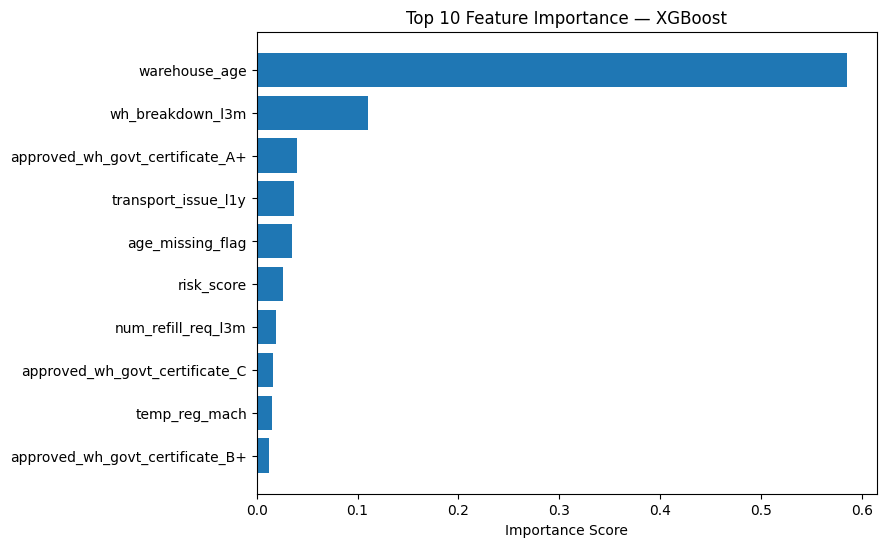

In [ ]:

importance = best_xgb.feature_importances_
features = x_train.columns

feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,6))
plt.barh(feat_imp['Feature'][:10], feat_imp['Importance'][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importance — XGBoost")
plt.xlabel("Importance Score")
plt.show()


Warehouse age is the most influential factor in shipment demand, contributing significantly more than other variables. Operational reliability factors such as recent warehouse breakdowns and transport issues also strongly impact shipment volumes. Compliance certification and infrastructure indicators show moderate influence on demand. From a business perspective, improving warehouse stability and modernizing older facilities can meaningfully enhance supply efficiency.

Learning Curve Plot

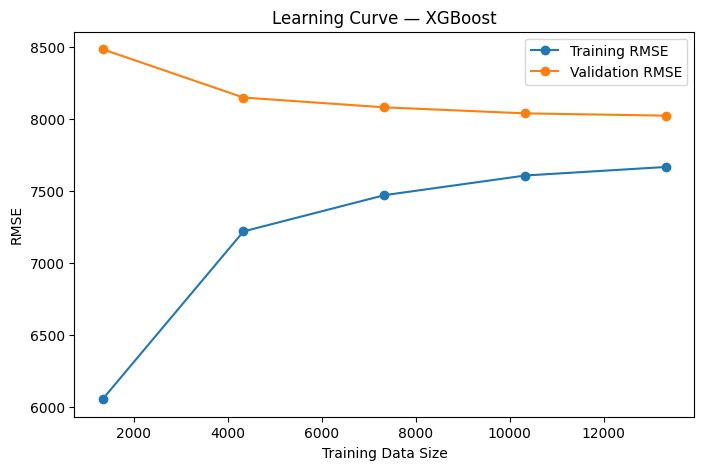

In [ ]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    best_xgb,
    x_train,
    y_train,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_rmse = -train_scores.mean(axis=1)
val_rmse   = -val_scores.mean(axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_rmse, marker='o', label='Training RMSE')
plt.plot(train_sizes, val_rmse, marker='o', label='Validation RMSE')
plt.xlabel("Training Data Size")
plt.ylabel("RMSE")
plt.title("Learning Curve — XGBoost")
plt.legend()
plt.show()


As training data increases, validation RMSE steadily decreases and stabilizes, indicating improved model generalization. The gap between training and validation error narrows with more data, showing reduced overfitting. Both curves flatten toward the end, suggesting the model has learned most demand patterns. From a business perspective, the model is stable and reliable for large-scale shipment forecasting.

INSIGHTS/OBSERVATIONS BASED ON EDA

• Shipment quantity varies widely across warehouses, indicating
uneven demand distribution and confirming the need for demand-
based allocation rather than fixed supply.

• Retail shop coverage and distributor network strongly influence
shipment volume, showing that product allocation is primarily driven
by market reach.

• Warehouse capacity and workforce size represent operational
capability, as larger and better-staffed warehouses tend to handle
higher stock movement.

• Regional zones alone do not fully explain demand variation,
suggesting local market factors are more important than broad
geographic classification

• Distance from the production hub does not significantly affect
shipment quantity, meaning supply decisions are demand-driven
rather than proximity-driven.

• Operational risk indicators (breakdowns, infrastructure conditions,
and disruptions) impact shipment handling and should be considered
in planning.

• The presence of multiple demand levels across warehouses indicates
the company serves heterogeneous markets such as low, medium,
and high consumption areas.

Actionable Insights & Recommendations

Key Insights from Analysis:

• Shipment demand varies significantly across warehouses, indicating
diverse regional consumption patterns and the need for demand-
driven allocation rather than uniform distribution.

• Warehouse infrastructure and operational factors such as workforce
size, retail network coverage, and distance from the production hub
strongly influence shipment volume.

• Ensemble machine learning models substantially improved demand
forecasting accuracy, with tuned XGBoost explaining over 53% of
demand variation and delivering the lowest prediction error.

• The presence of extreme shipment values and uneven regional
demand highlights the inefficiency of fixed allocation strategies
currently used in supply planning.


Actionable Business Recommendations:

1. Create a “Demand Heatmap Control Tower”

What: Build a live dashboard that shows predicted shipment demand by
region, warehouse load, and stock risk.

Why: Managers currently react after stock problems occur.

Impact:
• Proactive inventory decisions
• Early shortage alerts
• Faster executive decisions

Business Value:
Turns supply chain from reactive → predictive operations.

2. Smart Auto-Replenishment System

What: Integrate the ML model into ERP to automatically trigger stock refills
when predicted demand crosses threshold.

Why:Manual approvals slow supply chain response.

Impact:
• Faster replenishment
• Fewer stockouts
• Lower working capital blockage

Business Value:
Reduces operational delays and improves service level.

3. Regional Demand-Based Marketing Allocation

What:Use demand predictions to decide ad spend region-wise.

Example:

High predicted demand → push promotions
Low demand → avoid over-promotion

Impact:
• Smarter marketing spend
• Prevent artificial demand spikes
• Better ROI on campaigns

Business Value:
Aligns marketing with supply capability.

4. Warehouse Modernization Prioritization

Insight Used: Warehouse age is most important factor.

What: Rank warehouses by modernization need.

Actions:
• Upgrade oldest warehouses first
• Improve infrastructure & automation

Impact:
• Higher throughput
• Fewer breakdowns
• Better demand servicing

Business Value:
CapEx guided by data, not assumptions.

5. Dynamic Logistics Route Optimization

What:Use demand + distance data to optimize shipment routes daily.

Impact:
• Lower fuel costs
• Faster deliveries
• Better vehicle utilization

Business Value:
Reduces logistics cost per ton shipped.

6. Warehouse Risk Scoring & Insurance Strategy

Insight Used:Breakdowns, transport issues affect demand.

What:Create risk score per warehouse and align insurance coverage &
safety audits.

Impact:
• Lower operational disruption
• Lower claim losses
• Safer supply chain

Business Value:
Risk-managed distribution network.

7. Tier-Based Supply Strategy

What:Segment warehouses:

Tier--> Strategy

High-demand--> Priority supply, buffer stock

Medium--> Balanced allocation

Low-demand--> Lean inventory

Impact:
• Prevent overstock
• Reduce wastage
• Improve availability

Business Value:
Right stock at right place.